## Wave Adder

## Adding two sine waves

In [1]:
import numpy as np

from constants import DEFAULT_SAMPLE_RATE


def fplot_xy(wave, fslice=slice(0, 100), sample_rate=44100):
    fd = np.fft.fft(wave)
    fd_mag = np.abs(fd)
    x = np.linspace(0, sample_rate, len(wave))
    y = fd_mag * 2 / sample_rate
    return x[fslice], y[fslice]

In [ ]:
import matplotlib.pyplot as plt

from engine import SineOscillator, WaveAdder

osc1 = SineOscillator(freq=1, amp=1, phase=0, sample_rate=512)
osc2 = SineOscillator(freq=4, amp=0.5, phase=0, sample_rate=512)
adder = WaveAdder(osc1, osc2)
samples = adder.get_samples(n=512 * 5)
fft_x, fft_y = fplot_xy(samples)

fig, ax = plt.subplots(1, 2, figsize=(25, 6))
ax[0].plot(samples)
ax[0].set_title("Time Domain")
ax[0].set_xlabel("Samples")
ax[0].set_ylabel("Amplitude")

ax[1].plot(fft_x, fft_y)
ax[1].set_title("Frequency Spectrum")
ax[1].set_xlabel("Frequency (Hz)")
ax[1].set_ylabel("Magnitude")
plt.show()

## Adding sine and square waves

In [ ]:
import matplotlib.pyplot as plt

from engine import SineOscillator, SquareOscillator, WaveAdder

osc1 = SineOscillator(freq=1, amp=1, phase=0, sample_rate=512)
osc2 = SquareOscillator(freq=4, amp=0.5, phase=45, sample_rate=512)
adder = WaveAdder(osc1, osc2)

samples = adder.get_samples(n=512 * 5)
fft_x, fft_y = fplot_xy(samples)

fig, ax = plt.subplots(1, 2, figsize=(25, 6))
ax[0].plot(samples)
ax[0].set_title("Time Domain")
ax[0].set_xlabel("Samples")
ax[0].set_ylabel("Amplitude")

ax[1].plot(fft_x, fft_y)
ax[1].set_title("Frequency Spectrum")
ax[1].set_xlabel("Frequency (Hz)")
ax[1].set_ylabel("Magnitude")
plt.show()

## Creating a complex waveform with multiple oscillators

In [4]:
from utils import wave_to_file
from engine import TriangleOscillator

dur = 10
osc = WaveAdder(
    SquareOscillator(27.5, amp=0.1),
    TriangleOscillator(55, amp=0.5),
    SineOscillator(110),
    SquareOscillator(220, amp=0.1),
    SineOscillator(440, amp=0.3),
    TriangleOscillator(880, amp=0.05),
)
wav = osc.get_samples(44100 * dur)

osc2 = WaveAdder(
    SquareOscillator(27.5, amp=0.1),
    TriangleOscillator(55, amp=0.5),
    SineOscillator(115),
    SquareOscillator(220, amp=0.1),
    SineOscillator(440, amp=0.3),
    TriangleOscillator(880, amp=0.05),
)
wav2 = osc2.get_samples(44100 * dur)

wave_to_file(wav, wav2, fname="ot_vibes.wav")

## A Min 6

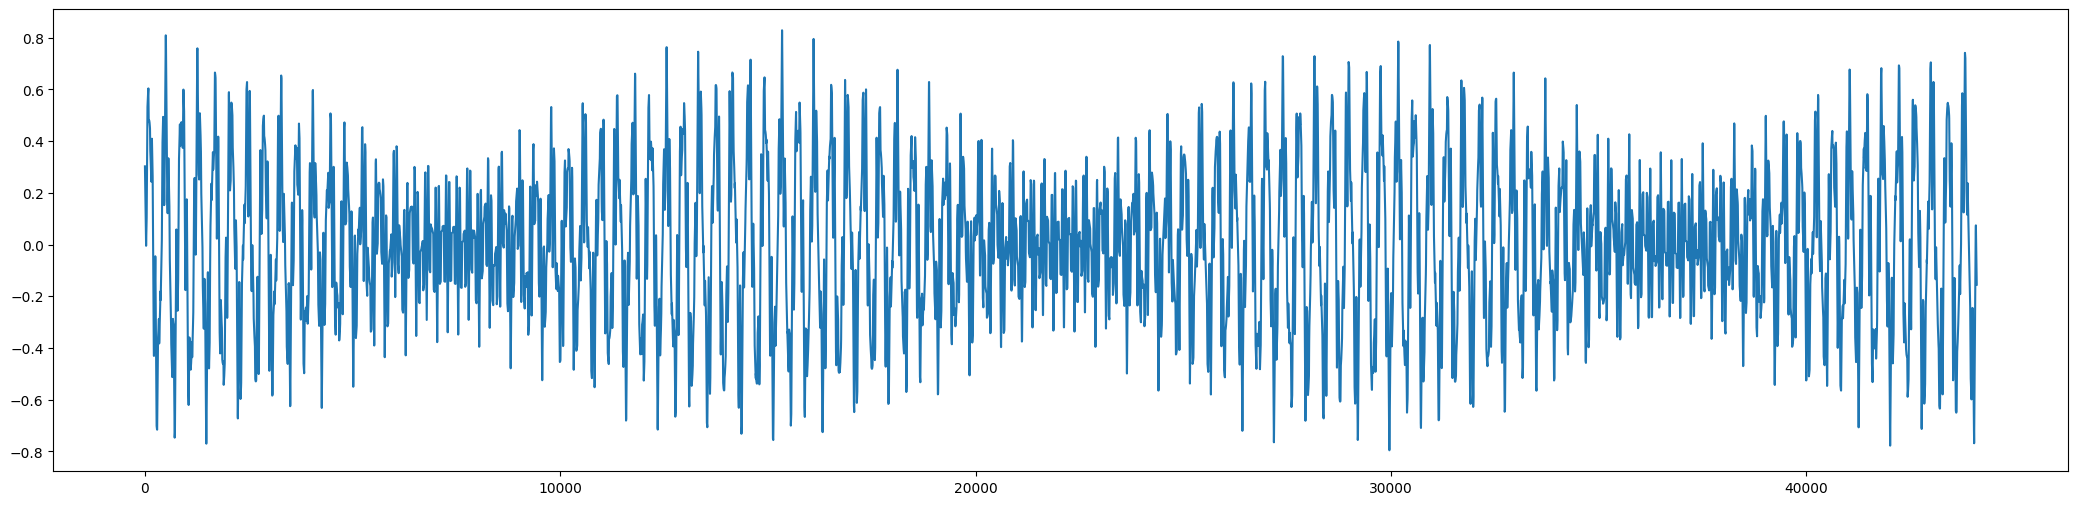

In [5]:
import librosa


def get_seq(osc, notes=["C4", "E4", "G4"], note_lens=[0.5, 0.5, 0.5]):
    samples = []
    osc = iter(osc)
    for note, note_len in zip(notes, note_lens):
        osc.freq = librosa.note_to_hz(note)
        for _ in range(int(DEFAULT_SAMPLE_RATE * note_len)):
            samples.append(next(osc))
    return samples


dur = 10
osc = WaveAdder(
    SineOscillator(librosa.note_to_hz("A2")),
    SineOscillator(librosa.note_to_hz("A2") + 3),
    TriangleOscillator(librosa.note_to_hz("A4"), amp=0.6),
    TriangleOscillator(librosa.note_to_hz("E5"), amp=0.8),
)
wav = osc.get_samples(44100 * dur)

osc2 = WaveAdder(
    SineOscillator(librosa.note_to_hz("A2")),
    SineOscillator(librosa.note_to_hz("A2") + 3),
    TriangleOscillator(librosa.note_to_hz("C5"), amp=0.8),
    TriangleOscillator(librosa.note_to_hz("F5"), amp=0.6),
)
wav2 = osc2.get_samples(44100 * dur)


wave_to_file(wav, wav2, fname="a_min6.wav")

plt.figure(figsize=(26, 6))
samples = osc2.get_samples(44100)
plt.plot(samples)
plt.show()

## C Maj 7

In [6]:
dur = 10
s1 = ["C4", "E4", "G4", "B4"] * dur
l1 = [0.25, 0.25, 0.25, 0.25] * dur

s2 = ["C3", "E3", "G3"] * dur
l2 = [0.333334, 0.333334, 0.333334] * dur

s3 = ["C2", "G2"] * dur
l3 = [0.5, 0.5] * dur

wavl = (
    np.array(get_seq(TriangleOscillator(amp=0.8), notes=s1, note_lens=l1))
    + np.array(get_seq(SineOscillator(), notes=s2, note_lens=l2))
    + np.array(get_seq(TriangleOscillator(amp=0.4), notes=s3, note_lens=l3))
)

wavr = (
    np.array(get_seq(TriangleOscillator(amp=0.8), notes=s1[::-1], note_lens=l1))
    + np.array(get_seq(SineOscillator(), notes=s2[::-1], note_lens=l2))
    + np.array(get_seq(TriangleOscillator(amp=0.4), notes=s3[::-1], note_lens=l3))
)

wave_to_file(wavl, wavr, fname="c_maj7.wav")